# 🕵️‍♂️ 05 - Gözetimsiz Makine Öğrenmesi (Unsupervised Learning)
## Uydu Telemetri Anomali Tespiti

**Amaç:** Etiket kullanmadan anomali tespiti. Modeller sadece Normal verilerle eğitilir.

### Modeller:
1. Isolation Forest
2. One-Class SVM
3. K-Means Clustering
4. Local Outlier Factor (LOF)
5. Autoencoder (Derin Öğrenme)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import json, warnings, joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, roc_auc_score, roc_curve, auc
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.cluster import KMeans
from sklearn.neighbors import LocalOutlierFactor

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
print('✅ Kütüphaneler yüklendi.')


✅ Kütüphaneler yüklendi.


---
## 📥 Bölüm 0: Veri Hazırlama


In [2]:
df_features = pd.read_parquet('../data/features/segment_features.parquet')
drop_cols = ['segment', 'anomaly', 'train', 'channel']
feature_cols = [c for c in df_features.columns if c not in drop_cols]
X = df_features[feature_cols].fillna(0)
y = df_features['anomaly']

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.15, random_state=42, stratify=y_trainval)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

normal_mask = (y_train == 0).values
X_normal_train = X_train_s[normal_mask]

print(f"Eğitim (Normal): {X_normal_train.shape}, Val: {X_val_s.shape}, Test: {X_test_s.shape}")

def find_best_threshold(scores, y_true):
    best_f1, best_t = 0, np.percentile(scores, 90)
    for p in np.arange(40, 99.5, 0.5):
        t = np.percentile(scores, p)
        preds = (scores > t).astype(int)
        f = f1_score(y_true, preds, zero_division=0)
        if f > best_f1: best_f1, best_t = f, t
    return best_t, best_f1


Eğitim (Normal): (1148, 24), Val: (255, 24), Test: (425, 24)


---
## 🌲 Bölüm 1: Isolation Forest


              precision    recall  f1-score   support

      Normal       0.86      0.78      0.82       338
     Anomali       0.37      0.49      0.42        87

    accuracy                           0.72       425
   macro avg       0.61      0.64      0.62       425
weighted avg       0.76      0.72      0.74       425

AUC: 0.7145


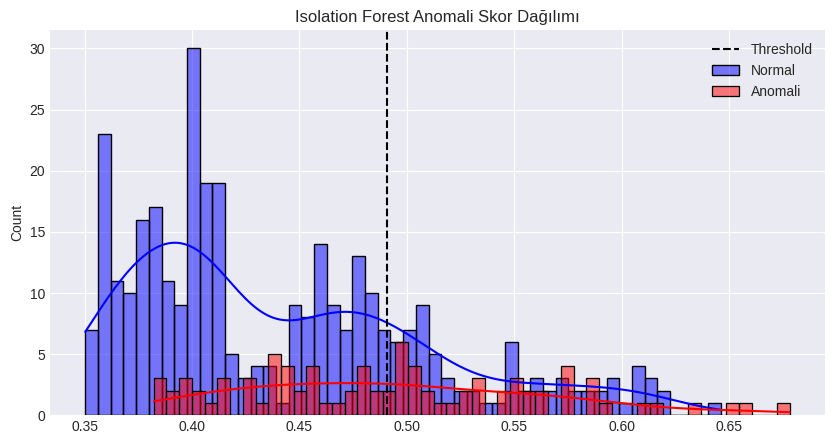

In [3]:
iso = IsolationForest(n_estimators=200, max_features=0.75, contamination=0.05, random_state=42, n_jobs=-1)
iso.fit(X_normal_train)

scores_val = -iso.score_samples(X_val_s)
iso_thresh, val_f1 = find_best_threshold(scores_val, y_val.values)
scores_test = -iso.score_samples(X_test_s)
y_pred = (scores_test > iso_thresh).astype(int)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomali']))
print(f"AUC: {roc_auc_score(y_test, scores_test):.4f}")

plt.figure(figsize=(10, 5))
sns.histplot(scores_test[y_test==0], color='blue', label='Normal', kde=True, bins=50)
sns.histplot(scores_test[y_test==1], color='red', label='Anomali', kde=True, bins=50)
plt.axvline(x=iso_thresh, color='black', linestyle='--', label='Threshold')
plt.title('Isolation Forest Anomali Skor Dağılımı'); plt.legend(); plt.show()


---
## ⚔️ Bölüm 2: One-Class SVM


In [4]:
ocsvm = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.05)
ocsvm.fit(X_normal_train)
scores_val = -ocsvm.decision_function(X_val_s)
ocsvm_thresh, _ = find_best_threshold(scores_val, y_val.values)
scores_test = -ocsvm.decision_function(X_test_s)
y_pred = (scores_test > ocsvm_thresh).astype(int)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomali']))
print(f"AUC: {roc_auc_score(y_test, scores_test):.4f}")


              precision    recall  f1-score   support

      Normal       0.92      0.93      0.92       338
     Anomali       0.70      0.68      0.69        87

    accuracy                           0.88       425
   macro avg       0.81      0.80      0.81       425
weighted avg       0.87      0.88      0.87       425

AUC: 0.8580


---
## 🎯 Bölüm 3: K-Means Clustering


              precision    recall  f1-score   support

      Normal       0.93      0.83      0.87       338
     Anomali       0.53      0.76      0.62        87

    accuracy                           0.81       425
   macro avg       0.73      0.79      0.75       425
weighted avg       0.85      0.81      0.82       425

AUC: 0.8685


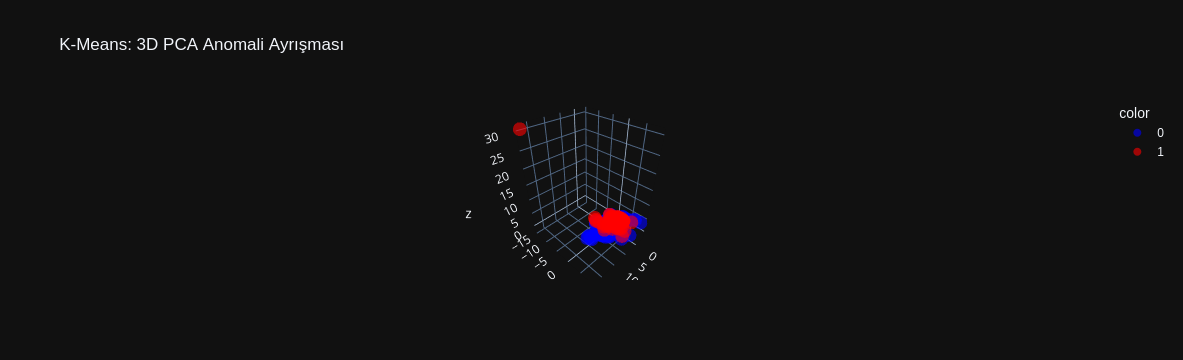

In [5]:
km = KMeans(n_clusters=10, random_state=42, n_init='auto')
km.fit(X_normal_train)
scores_val = np.min(km.transform(X_val_s), axis=1)
km_thresh, _ = find_best_threshold(scores_val, y_val.values)
scores_test = np.min(km.transform(X_test_s), axis=1)
y_pred = (scores_test > km_thresh).astype(int)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomali']))
print(f"AUC: {roc_auc_score(y_test, scores_test):.4f}")

from sklearn.decomposition import PCA
pca = PCA(n_components=3); X_pca = pca.fit_transform(X_test_s)
fig = px.scatter_3d(x=X_pca[:,0], y=X_pca[:,1], z=X_pca[:,2], color=y_test.astype(str),
                    color_discrete_map={'0':'blue','1':'red'}, opacity=0.6,
                    title="K-Means: 3D PCA Anomali Ayrışması")
fig.update_layout(template='plotly_dark'); fig.show()


---
## 🔍 Bölüm 4: Local Outlier Factor (LOF)


In [6]:
lof = LocalOutlierFactor(n_neighbors=10, novelty=True, contamination=float(y_train.mean()))
lof.fit(X_normal_train)
scores_val = -lof.score_samples(X_val_s)
lof_thresh, _ = find_best_threshold(scores_val, y_val.values)
scores_test = -lof.score_samples(X_test_s)
y_pred = (scores_test > lof_thresh).astype(int)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomali']))
print(f"AUC: {roc_auc_score(y_test, scores_test):.4f}")


              precision    recall  f1-score   support

      Normal       0.94      0.90      0.92       338
     Anomali       0.68      0.79      0.73        87

    accuracy                           0.88       425
   macro avg       0.81      0.85      0.83       425
weighted avg       0.89      0.88      0.88       425

AUC: 0.9351


---
## 🧠 Bölüm 5: Autoencoder (Derin Öğrenme)


I0000 00:00:1780425240.973662  297855 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780425241.006341  297855 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780425242.166310  297855 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Epoch 1/150


W0000 00:00:1780425242.699706  297855 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.2680 - val_loss: 0.6658
Epoch 2/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5411 - val_loss: 0.5207
Epoch 3/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3450 - val_loss: 0.3960
Epoch 4/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2666 - val_loss: 0.2995
Epoch 5/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2242 - val_loss: 0.2329
Epoch 6/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2102 - val_loss: 0.1753
Epoch 7/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2000 - val_loss: 0.1412
Epoch 8/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1746 - val_loss: 0.1137
Epoch 9/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1583 - val_loss: 0.0957
Epoch 10/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1673 - val_loss: 0.0841
Epoch 11/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1502 - val_loss: 0.0774
Epoch 12/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1509 - val_lo

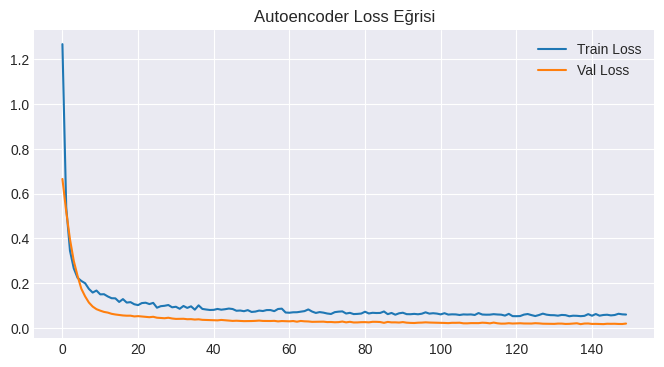

              precision    recall  f1-score   support

      Normal       0.94      0.94      0.94       338
     Anomali       0.76      0.76      0.76        87

    accuracy                           0.90       425
   macro avg       0.85      0.85      0.85       425
weighted avg       0.90      0.90      0.90       425

AUC: 0.9480


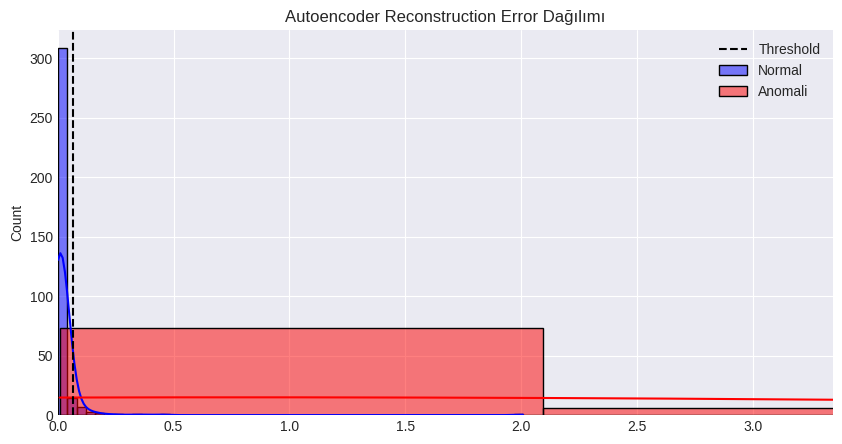

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

ae = Sequential([
    Dense(64, activation='relu', input_shape=(X_normal_train.shape[1],)),
    BatchNormalization(), Dropout(0.2),
    Dense(32, activation='relu'), BatchNormalization(),
    Dense(16, activation='relu'),
    Dense(32, activation='relu'), BatchNormalization(),
    Dense(64, activation='relu'), BatchNormalization(),
    Dense(X_normal_train.shape[1], activation='linear')
])
ae.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
X_normal_val = X_val_s[y_val.values == 0]
history = ae.fit(X_normal_train, X_normal_train, validation_data=(X_normal_val, X_normal_val),
                 epochs=150, batch_size=32, callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)], verbose=1)

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss'); plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Loss Eğrisi'); plt.legend(); plt.show()

recon_val = ae.predict(X_val_s, verbose=0)
scores_val = np.mean(np.power(X_val_s - recon_val, 2), axis=1)
ae_thresh, _ = find_best_threshold(scores_val, y_val.values)
recon_test = ae.predict(X_test_s, verbose=0)
scores_test = np.mean(np.power(X_test_s - recon_test, 2), axis=1)
y_pred = (scores_test > ae_thresh).astype(int)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomali']))
print(f"AUC: {roc_auc_score(y_test, scores_test):.4f}")

plt.figure(figsize=(10, 5))
sns.histplot(scores_test[y_test==0], color='blue', label='Normal', kde=True, bins=50)
sns.histplot(scores_test[y_test==1], color='red', label='Anomali', kde=True, bins=50)
plt.axvline(x=ae_thresh, color='black', linestyle='--', label='Threshold')
plt.title('Autoencoder Reconstruction Error Dağılımı')
plt.xlim([0, np.percentile(scores_test, 98)]); plt.legend(); plt.show()


---
## 🤝 Bölüm 6: ROC Karşılaştırması


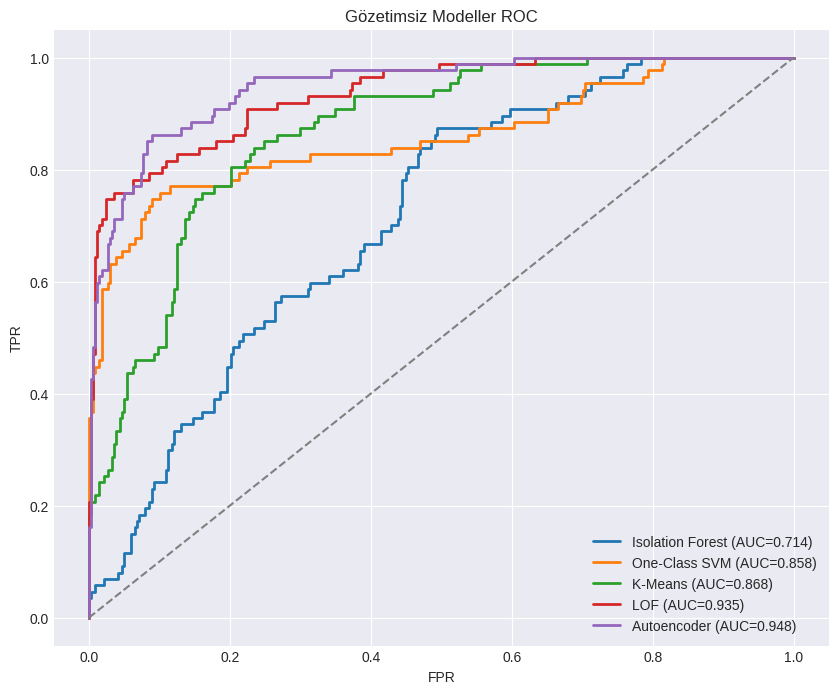

In [8]:
plt.figure(figsize=(10, 8))
all_scores = {
    'Isolation Forest': -iso.score_samples(X_test_s),
    'One-Class SVM': -ocsvm.decision_function(X_test_s),
    'K-Means': np.min(km.transform(X_test_s), axis=1),
    'LOF': -lof.score_samples(X_test_s),
    'Autoencoder': np.mean(np.power(X_test_s - ae.predict(X_test_s, verbose=0), 2), axis=1)
}
for name, sc in all_scores.items():
    fpr,tpr,_ = roc_curve(y_test, sc); ra = auc(fpr,tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={ra:.3f})')
plt.plot([0,1],[0,1],color='gray',linestyle='--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('Gözetimsiz Modeller ROC'); plt.legend(loc='lower right')
plt.show()


---
## 💾 Bölüm 7: Kaydetme


In [9]:
import os
os.makedirs('../models/unsupervised', exist_ok=True)
joblib.dump(iso, '../models/unsupervised/isolationforest_model.joblib')
joblib.dump(ocsvm, '../models/unsupervised/oneclasssvm_model.joblib')
joblib.dump(km, '../models/unsupervised/kmeans_model.joblib')
joblib.dump(lof, '../models/unsupervised/lof_model.joblib')
ae.save('../models/unsupervised/autoencoder_model.keras')
thresholds = {'IsolationForest':float(iso_thresh),'OneClassSVM':float(ocsvm_thresh),'KMeans':float(km_thresh),'LOF':float(lof_thresh),'Autoencoder':float(ae_thresh)}
with open('../models/unsupervised/unsupervised_thresholds.json','w') as f: json.dump(thresholds,f,indent=2)
print("✅ Tüm gözetimsiz modeller kaydedildi.")


✅ Tüm gözetimsiz modeller kaydedildi.


---
## Ek Gözetimsiz Modeller (sklearn + Derin + PyOD)

Mevcut 5 modele ek olarak **9 yeni gözetimsiz dedektör**:

**sklearn / derin (5):** GMM, Elliptic Envelope, PCA (reconstruction error), DBSCAN (core-distance novelty), VAE

**PyOD (4):** ECOD, COPOD, HBOS, CBLOF — *yalnızca `pip install pyod` kuruluysa eğitilir.*

In [10]:
# --- Ek Gözetimsiz Modeller: GMM, Elliptic Envelope, PCA, DBSCAN, VAE + PyOD (ECOD/COPOD/HBOS/CBLOF) ---
import sys, os, json, joblib
sys.path.insert(0, '..')
from src.models.unsupervised import UnsupervisedAnomalyDetector

uns = UnsupervisedAnomalyDetector(random_state=42)
uns.train_gmm(X_normal_train)
uns.train_elliptic_envelope(X_normal_train)
uns.train_pca(X_normal_train)
uns.train_dbscan(X_normal_train)
uns.train_vae(X_normal_train, X_val_s)
uns.train_pyod(X_normal_train)   # PyOD kuruluysa ECOD/COPOD/HBOS/CBLOF

# Kaydet (mevcut 5 modeli ezmeden, isimleri model_loader ile eslesir)
UNS_DIR = '../models/unsupervised'
os.makedirs(UNS_DIR, exist_ok=True)
ext_files = {
    'GMM': 'gmm_model.joblib', 'EllipticEnvelope': 'ellipticenvelope_model.joblib',
    'PCA': 'pca_model.joblib', 'DBSCAN': 'dbscan_model.joblib', 'VAE': 'vae_model.keras',
    'ECOD': 'ecod_model.joblib', 'COPOD': 'copod_model.joblib',
    'HBOS': 'hbos_model.joblib', 'CBLOF': 'cblof_model.joblib',
}
for name, fname in ext_files.items():
    if name not in uns.models:
        continue
    path = os.path.join(UNS_DIR, fname)
    if name == 'VAE':
        uns.models[name].save(path)
    else:
        joblib.dump(uns.models[name], path)

# Esik degerlerini mevcut JSON ile birlestir (orijinal 5 modeli koru)
tp = os.path.join(UNS_DIR, 'unsupervised_thresholds.json')
existing = json.load(open(tp)) if os.path.exists(tp) else {}
existing.update({k: float(v) for k, v in uns.thresholds.items()})
json.dump(existing, open(tp, 'w'), indent=2)
print('OK - ek gozetimsiz modeller kaydedildi:', [k for k in ext_files if k in uns.models])

🔔 Gaussian Mixture Model eğitiliyor...
🥚 Elliptic Envelope eğitiliyor...
📉 PCA (reconstruction error) eğitiliyor...
🌌 DBSCAN (core-distance novelty) eğitiliyor...
🧠 Variational Autoencoder (VAE) eğitiliyor...
Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 5.5613 - val_loss: 1.5384
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1873 - val_loss: 1.3886
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.5436 - val_loss: 1.3405
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2981 - val_loss: 1.3353
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1802 - val_loss: 1.3180
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1088 - val_loss: 1.3153
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0574 - val_loss: 1.3242
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0217 - val_loss: 1.3380
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9821 - val_loss: 1.3519
Epoch 10/50
18/18 ━━━━━━━━━━━━━━━━

### HTML Rapor


In [11]:
%pip install jupyter nbconvert -q
!jupyter nbconvert --to html 05_model_unsupervised.ipynb --output ../reports/05_model_unsupervised_rapor.html



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
[NbConvertApp] Converting notebook 05_model_unsupervised.ipynb to html
/home/keskin/Uydu-Telemetri-Anomali-Tespiti/venv/lib64/python3.11/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
/home/keskin/Uydu-Telemetri-Anomali-Tespiti/venv/share/jupyter/nbconvert/templates/base/display_priority.j2:32: UserWarning: Your element with mimetype(s) dict_keys(['application/vnd.plotly.v1+json']) is not able to be represented.
  {%- elif type == 'text/vnd.mermaid' -%}
[NbConvertApp] WARNING | Alternativ